# PCA USE IN DIMENSIONALITY REDUCTION

# Mathematics behiend PCA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn import preprocessing

from sklearn.decomposition import PCA

from warnings import filterwarnings
filterwarnings("ignore")
import os
os.getcwd()

'C:\\Users\\User\\Desktop\\Batch Dec12th Stats ML\\Jan_27_PCA'

In [2]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 100)

In [3]:
df = pd.read_csv("data.csv")

In [4]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
"""
# Create a dictionary using which we
# will remap the values
dict = {'M' : 1, 'B' : 0}
 
# Print the dictionary
print(dict)
 
# Remap the values of the dataframe
df.replace({"diagnosis": dict})
"""

'\n# Create a dictionary using which we\n# will remap the values\ndict = {\'M\' : 1, \'B\' : 0}\n \n# Print the dictionary\nprint(dict)\n \n# Remap the values of the dataframe\ndf.replace({"diagnosis": dict})\n'

In [6]:
df["diagnosis"]=df["diagnosis"].map({"M":1,"B":1})

In [7]:
df.drop("Unnamed: 32",axis=1,inplace=True)


In [8]:
X=df.drop("diagnosis",axis=1)
Y=df["diagnosis"]

In [9]:
X.shape

(569, 31)

In [10]:
X.head()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [11]:
"""
#One of the best methods for dimenionality reduction is principle component analysis(PCA)
#PCA is a linear dimensionality reduction technique. 
#It transforms a set of correlated variables (p) into a smaller k (k<p) 
number of uncorrelated variables called 
#principal components while retaining as much of the variation in the original dataset as possible.
#The most important part in PCA is selecting the best number of components for the given dataset.
"""

'\n#One of the best methods for dimenionality reduction is principle component analysis(PCA)\n#PCA is a linear dimensionality reduction technique. \n#It transforms a set of correlated variables (p) into a smaller k (k<p) \nnumber of uncorrelated variables called \n#principal components while retaining as much of the variation in the original dataset as possible.\n#The most important part in PCA is selecting the best number of components for the given dataset.\n'

In [12]:
# It is important to do the feature scaling before applying pca as 
#to scale down all the numbers in the DF as the 
#PCA directions are highly sensitive to the scale of the data.

In [13]:
scaler = StandardScaler()

In [14]:
scaled_X = scaler.fit_transform(X)

In [15]:
scaled_X

array([[-0.23640517,  1.09706398, -2.07333501, ...,  2.29607613,
         2.75062224,  1.93701461],
       [-0.23640344,  1.82982061, -0.35363241, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 0.43174109,  1.57988811,  0.45618695, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [-0.23572747,  0.70228425,  2.0455738 , ...,  0.41406869,
        -1.10454895, -0.31840916],
       [-0.23572517,  1.83834103,  2.33645719, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-0.24240586, -1.80840125,  1.22179204, ..., -1.74506282,
        -0.04813821, -0.75120669]])

In [16]:
scaled_X_df=pd.DataFrame(scaled_X,columns=X.columns)

In [17]:
scaled_X_df.head()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,-0.236405,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,2.489734,-0.565265,2.833031,2.487578,-0.214002,1.316862,0.724026,0.660820,1.148757,0.907083,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,-0.236403,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,0.499255,-0.876244,0.263327,0.742402,-0.605351,-0.692926,-0.440780,0.260162,-0.805450,-0.099444,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,0.431741,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,1.228676,-0.780083,0.850928,1.181336,-0.297005,0.814974,0.213076,1.424827,0.237036,0.293559,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,0.432121,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,0.326373,-0.110409,0.286593,-0.288378,0.689702,2.744280,0.819518,1.115007,4.732680,2.047511,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,0.432201,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,1.270543,-0.790244,1.273189,1.190357,1.483067,-0.048520,0.828471,1.144205,-0.361092,0.499328,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [18]:
"""Steps of PCA

(1)After Getting original data, calculate covariance matrix.

(2)Calculate EigenVectors.

(3)Sort EigenVectors by Eigenvalues.

(4)Choose N largest EigenValues.

(5)Project Original data onto EigenVectors."""

'Steps of PCA\n\n(1)After Getting original data, calculate covariance matrix.\n\n(2)Calculate EigenVectors.\n\n(3)Sort EigenVectors by Eigenvalues.\n\n(4)Choose N largest EigenValues.\n\n(5)Project Original data onto EigenVectors.'

In [19]:
from sklearn.decomposition import PCA

# step 1:-calculate covariance matrix

In [20]:
covariance_matrix1=scaled_X_df.cov()

In [21]:
covariance_matrix1

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,1.001761,0.074758,0.099946,0.073288,0.097063,-0.012991,0.000096,0.050168,0.044236,-0.022153,-0.052604,0.143299,-0.007539,0.137573,0.178055,0.096951,0.034021,0.055337,0.078907,-0.017337,0.025771,0.082550,0.064833,0.080127,0.107375,0.010356,-0.002973,0.023244,0.035236,-0.044302,-0.029918
radius_mean,0.074758,1.001761,0.324352,0.999612,0.989095,0.170882,0.507015,0.677955,0.823977,0.148001,-0.312179,0.680286,-0.097489,0.675359,0.737159,-0.222992,0.206363,0.194546,0.376831,-0.104505,-0.042716,0.971246,0.297531,0.966836,0.942739,0.119827,0.414191,0.527839,0.745524,0.164242,0.007078
texture_mean,0.099946,0.324352,1.001761,0.330113,0.321651,-0.023430,0.237119,0.302950,0.293981,0.071527,-0.076572,0.276354,0.387038,0.282169,0.260302,0.006625,0.192313,0.143545,0.164139,0.009143,0.054553,0.353194,0.913650,0.358670,0.344151,0.077640,0.278319,0.301555,0.295836,0.105193,0.119415
perimeter_mean,0.073288,0.999612,0.330113,1.001761,0.988244,0.207643,0.557917,0.717396,0.852475,0.183349,-0.261937,0.692983,-0.086914,0.694355,0.746294,-0.203051,0.251185,0.228484,0.407934,-0.081773,-0.005533,0.971183,0.303572,0.972095,0.943207,0.150814,0.456577,0.564872,0.772599,0.189448,0.051108
area_mean,0.097063,0.989095,0.321651,0.988244,1.001761,0.177340,0.499379,0.687191,0.824718,0.151559,-0.283608,0.733852,-0.066397,0.727908,0.801495,-0.167070,0.212957,0.208026,0.372976,-0.072624,-0.019922,0.964441,0.287995,0.960808,0.960902,0.123740,0.391098,0.513508,0.723288,0.143823,0.003744
smoothness_mean,-0.012991,0.170882,-0.023430,0.207643,0.177340,1.001761,0.660284,0.522903,0.554670,0.558757,0.585822,0.301998,0.068527,0.296613,0.246987,0.332961,0.319505,0.248833,0.381346,0.201128,0.284106,0.213495,0.036135,0.239273,0.207082,0.806742,0.473300,0.435691,0.503939,0.395004,0.500195
compactness_mean,0.000096,0.507015,0.237119,0.557917,0.499379,0.660284,1.001761,0.884675,0.832598,0.603702,0.566364,0.498349,0.046286,0.549872,0.456455,0.135537,0.740022,0.571521,0.643393,0.230381,0.508211,0.536258,0.248570,0.591250,0.510501,0.566537,0.867333,0.817712,0.817009,0.511122,0.688593
concavity_mean,0.050168,0.677955,0.302950,0.717396,0.687191,0.522903,0.884675,1.001761,0.923013,0.501548,0.337376,0.633037,0.076353,0.661553,0.618514,0.098737,0.671459,0.692487,0.684463,0.178323,0.450092,0.689448,0.300407,0.730849,0.677177,0.449612,0.756297,0.885659,0.862839,0.410185,0.515836
concave points_mean,0.044236,0.823977,0.293981,0.852475,0.824718,0.554670,0.832598,0.923013,1.001761,0.463312,0.167211,0.699279,0.021517,0.711901,0.691514,0.027702,0.491288,0.439940,0.616718,0.095519,0.258037,0.831779,0.293267,0.857430,0.811055,0.453550,0.668629,0.753724,0.911758,0.376406,0.369310
symmetry_mean,-0.022153,0.148001,0.071527,0.183349,0.151559,0.558757,0.603702,0.501548,0.463312,1.001761,0.480766,0.303913,0.128278,0.314445,0.224365,0.187651,0.422402,0.343230,0.393990,0.449927,0.332370,0.186055,0.090810,0.219554,0.177505,0.427426,0.474033,0.434485,0.431054,0.701058,0.439185


In [22]:
covariance_matrix1.shape

(31, 31)

In [23]:
eigen_values1, eigen_vectors1 = np.linalg.eig(covariance_matrix1)

In [24]:
eigen_values1

array([1.33114519e+01, 5.70683496e+00, 2.84038694e+00, 1.98484548e+00,
       1.65171815e+00, 1.23684643e+00, 9.79995551e-01, 6.72935632e-01,
       4.61603682e-01, 4.03842838e-01, 3.49769685e-01, 2.94407846e-01,
       2.61606691e-01, 2.41755091e-01, 1.57250011e-01, 9.42942450e-02,
       7.99504590e-02, 5.91502270e-02, 5.26837847e-02, 4.92084099e-02,
       3.11254863e-02, 2.99939190e-02, 2.74788170e-02, 2.42917142e-02,
       1.80711203e-02, 1.55069827e-02, 8.18608563e-03, 6.91024741e-03,
       1.33274432e-04, 7.49693618e-04, 1.59213568e-03])

In [25]:
print(len(eigen_values1))

31


In [26]:
# THERE ARE 31 Eigen Values because we have 31 independent variables(columns)

In [27]:
eigen_vectors1

array([[-2.29121629e-02, -3.40684907e-02, -9.69384357e-02,
        -2.65980453e-02, -1.13275871e-02, -3.16733438e-01,
        -9.07115632e-01,  9.63624150e-02,  1.49115642e-01,
         1.69267515e-01, -5.81889971e-02, -6.72125159e-03,
         4.84108383e-03, -6.50009912e-03, -6.88594292e-03,
         2.75349185e-03, -7.77998301e-03,  1.97073716e-02,
        -5.44224782e-03, -2.04549082e-02, -9.87091673e-03,
         6.19570677e-03,  3.19033693e-03, -1.02890273e-02,
        -4.23338835e-03, -1.32609967e-03, -2.57132397e-03,
         1.62387479e-03, -7.12258084e-05, -6.85226337e-04,
         1.89172407e-05],
       [-2.18913018e-01, -2.33271401e-01,  1.13937863e-02,
         4.21879503e-02,  3.81298606e-02,  2.95885214e-02,
         4.22987777e-02,  1.16427419e-01, -4.62708347e-02,
         2.24027044e-01,  7.94660810e-02, -4.22137877e-02,
        -5.06039273e-02, -1.24969877e-02,  5.90545533e-02,
        -5.07891563e-02,  1.50008977e-01, -2.09908003e-01,
         1.56773206e-01, -2.11

In [28]:
print(len(eigen_vectors1))

31


In [29]:
# we have 31 eigen vectors

In [30]:
covariance_matrix1.shape

(31, 31)

In [31]:
#covariance_matrix = np.cov(scaled_X, rowvar=False)

In [32]:
#covariance_matrix

In [33]:
#Now we will get Eigen Vectors and Eigen Values.

In [34]:
#eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [35]:
#eigen_values

In [36]:
imp1=pd.DataFrame(eigen_values1)

In [37]:
imp1.head(100)

,0
0,13.311452
1,5.706835
2,2.840387
3,1.984845
4,1.651718
5,1.236846
6,0.979996
7,0.672936
8,0.461604
9,0.403843


In [38]:
imp2=pd.DataFrame(eigen_vectors1)
imp2.head(100)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30
0,-0.022912,-0.034068,-0.096938,-0.026598,-0.011328,-0.316733,-0.907116,0.096362,0.149116,0.169268,-0.058189,-0.006721,0.004841,-0.006500,-0.006886,0.002753,-0.007780,0.019707,-0.005442,-0.020455,-0.009871,0.006196,0.003190,-0.010289,-0.004233,-0.001326,-0.002571,0.001624,-0.000071,-0.000685,0.000019
1,-0.218913,-0.233271,0.011394,0.042188,0.038130,0.029589,0.042299,0.116427,-0.046271,0.224027,0.079466,-0.042214,-0.050604,-0.012497,0.059055,-0.050789,0.150009,-0.209908,0.156773,-0.211821,-0.046010,0.070394,-0.073022,-0.098704,-0.183665,0.018594,0.128713,-0.131697,-0.702433,-0.211437,-0.211197
2,-0.103844,-0.060044,-0.066892,-0.602954,-0.049091,-0.031394,-0.014994,-0.001875,-0.088727,-0.119457,0.253258,0.304032,-0.256274,-0.201876,-0.020701,-0.108090,0.159153,0.034162,-0.040049,-0.029932,-0.264801,-0.436270,-0.095891,0.001311,0.099442,-0.084421,0.024821,-0.017623,-0.000264,0.010617,0.000064
3,-0.227535,-0.214589,0.012125,0.042753,0.037716,0.028394,0.043589,0.106272,-0.036231,0.226345,0.069866,-0.017573,-0.038470,-0.044684,0.048019,-0.039590,0.113793,-0.201234,0.168413,-0.227079,-0.015122,0.070963,-0.074822,-0.040501,-0.117262,-0.027435,0.124670,-0.115650,0.689868,-0.383889,-0.084343
4,-0.221046,-0.230669,-0.026293,0.054115,0.010562,0.006113,0.028926,0.047415,-0.080650,0.186004,0.062795,-0.110760,-0.065048,-0.067879,0.010152,0.014636,0.130174,-0.251460,0.269146,0.045500,-0.087345,0.021673,-0.097429,0.009396,0.070557,0.210571,-0.361015,0.467489,0.032972,0.422721,0.272517
5,-0.142415,0.186422,0.103182,0.158098,-0.365750,-0.262509,0.140340,0.123541,0.278996,0.061338,-0.084662,0.135322,-0.315872,-0.046462,0.444045,-0.117493,0.203118,-0.168172,-0.354463,0.160358,0.023842,0.117946,-0.063741,-0.020088,0.068940,-0.028761,0.037373,0.069483,0.004851,0.003464,-0.001480
6,-0.239067,0.152455,0.074769,0.031818,0.011787,-0.004904,0.045303,-0.043146,0.099214,0.195186,-0.005173,0.307036,0.104265,-0.230005,0.007661,0.230760,-0.170379,0.016303,0.014259,-0.292093,0.476396,-0.213188,0.094255,0.058295,-0.102198,-0.396513,-0.262695,0.098625,-0.044682,0.040908,0.005467
7,-0.258280,0.060542,-0.001759,0.019497,0.086513,-0.002356,0.032553,0.102436,0.075750,-0.033956,-0.134665,-0.124553,-0.065723,-0.387350,-0.189734,-0.128386,-0.270011,0.005072,-0.027974,-0.007197,-0.037771,-0.001270,0.188863,0.321063,0.045551,0.097180,0.550228,0.363040,-0.025129,0.010112,-0.045541
8,-0.260738,-0.034167,0.027580,0.065785,-0.043667,-0.034509,0.081422,0.136923,0.116569,0.142617,-0.006125,0.071565,-0.042253,-0.132638,-0.245219,-0.217300,-0.381112,-0.028742,-0.087066,0.153992,-0.231546,0.017493,0.313281,-0.057975,0.082350,0.186301,-0.389317,-0.453345,0.001068,0.004114,0.008886
9,-0.137978,0.190685,0.040962,0.067503,-0.305379,0.335082,-0.118259,0.098875,0.315150,-0.135615,0.574417,-0.161058,0.288054,-0.189571,0.030904,-0.073951,0.165691,0.194703,0.169169,0.058503,0.030777,0.085068,0.018331,-0.052005,0.018841,0.024511,0.015910,-0.015158,0.001280,0.007557,-0.001433


In [39]:
#Now we will sort EigenVectors by Eigenvalues.

In [40]:
sorted_key = np.argsort(eigen_values1)[::-1][:2]
sorted_key

array([0, 1], dtype=int64)

In [41]:
#Let's get num_components of Eigen Values and Eigen Vectors.

In [42]:
eigen_values, eigen_vectors = eigen_values1[sorted_key], eigen_vectors1[:, sorted_key]

In [43]:
eigen_values1

array([1.33114519e+01, 5.70683496e+00, 2.84038694e+00, 1.98484548e+00,
       1.65171815e+00, 1.23684643e+00, 9.79995551e-01, 6.72935632e-01,
       4.61603682e-01, 4.03842838e-01, 3.49769685e-01, 2.94407846e-01,
       2.61606691e-01, 2.41755091e-01, 1.57250011e-01, 9.42942450e-02,
       7.99504590e-02, 5.91502270e-02, 5.26837847e-02, 4.92084099e-02,
       3.11254863e-02, 2.99939190e-02, 2.74788170e-02, 2.42917142e-02,
       1.80711203e-02, 1.55069827e-02, 8.18608563e-03, 6.91024741e-03,
       1.33274432e-04, 7.49693618e-04, 1.59213568e-03])

In [44]:
eigen_vectors1

array([[-2.29121629e-02, -3.40684907e-02, -9.69384357e-02,
        -2.65980453e-02, -1.13275871e-02, -3.16733438e-01,
        -9.07115632e-01,  9.63624150e-02,  1.49115642e-01,
         1.69267515e-01, -5.81889971e-02, -6.72125159e-03,
         4.84108383e-03, -6.50009912e-03, -6.88594292e-03,
         2.75349185e-03, -7.77998301e-03,  1.97073716e-02,
        -5.44224782e-03, -2.04549082e-02, -9.87091673e-03,
         6.19570677e-03,  3.19033693e-03, -1.02890273e-02,
        -4.23338835e-03, -1.32609967e-03, -2.57132397e-03,
         1.62387479e-03, -7.12258084e-05, -6.85226337e-04,
         1.89172407e-05],
       [-2.18913018e-01, -2.33271401e-01,  1.13937863e-02,
         4.21879503e-02,  3.81298606e-02,  2.95885214e-02,
         4.22987777e-02,  1.16427419e-01, -4.62708347e-02,
         2.24027044e-01,  7.94660810e-02, -4.22137877e-02,
        -5.06039273e-02, -1.24969877e-02,  5.90545533e-02,
        -5.07891563e-02,  1.50008977e-01, -2.09908003e-01,
         1.56773206e-01, -2.11

In [45]:
#Dot product of original data and eigen_vectors are the principal component values. 
#This is the "projection" step of the original points on to the Principal Component.

In [46]:
principal_components=np.dot(scaled_X,eigen_vectors1)

In [47]:
principal_components

array([[-9.18319983e+00,  1.97127137e+00,  1.17162471e+00, ...,
        -4.71657487e-02, -4.55717832e-02,  3.39113949e-02],
       [-2.38329766e+00, -3.75345877e+00,  5.80228664e-01, ...,
        -1.84483129e-03,  5.90208043e-03, -3.26298575e-02],
       [-5.74247239e+00, -1.08035048e+00,  5.33087882e-01, ...,
         7.35346039e-04, -3.28969989e-03, -4.70218699e-02],
       ...,
       [-1.25189010e+00, -1.89397674e+00, -5.34466848e-01, ...,
         3.80807814e-03, -6.34033194e-03,  2.56758630e-03],
       [-1.03650353e+01,  1.69639755e+00,  1.90741785e+00, ...,
        -2.37630430e-02,  8.43022898e-02,  6.80834660e-02],
       [ 5.47826365e+00, -6.72788035e-01, -1.47716504e+00, ...,
        -1.94561856e-02,  6.10512178e-02,  9.51329032e-03]])

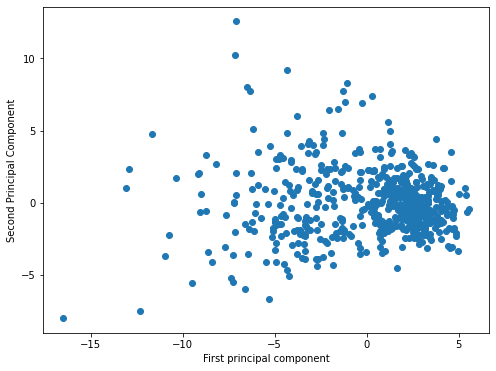

In [48]:
plt.figure(figsize=(8,6))
plt.scatter(principal_components[:,0],principal_components[:,1])
plt.xlabel('First principal component')
plt.ylabel('Second Principal Component')
plt.grid(False)
plt.show()

In [49]:
""" Model
For a real world example, we will use Breast Cancer Wisconsin dataset. 
Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. 
They describe characteristics of the cell nuclei present in the image.

It can be downloaded from here).

We will understand the dataset first.  """

' Model\nFor a real world example, we will use Breast Cancer Wisconsin dataset. \nFeatures are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. \nThey describe characteristics of the cell nuclei present in the image.\n\nIt can be downloaded from here).\n\nWe will understand the dataset first.  '

In [50]:
principal_components_1 = PCA(n_components=2)
fitted_principal_components_1 = principal_components_1.fit_transform(scaled_X)

In [51]:
fitted_principal_components_1

array([[ 9.18319983,  1.97127137],
       [ 2.38329766, -3.75345878],
       [ 5.74247239, -1.08035048],
       ...,
       [ 1.2518901 , -1.89397674],
       [10.36503528,  1.69639755],
       [-5.47826365, -0.67278803]])

In [52]:
component_df1 = pd.DataFrame(data=fitted_principal_components_1,columns=["First Component","Second Component"])

In [53]:
component_df1.head(10)

,First Component,Second Component
0,9.183200,1.971271
1,2.383298,-3.753459
2,5.742472,-1.080350
3,7.124384,10.272225
4,3.945694,-1.959689
5,2.371151,3.964910
6,2.233527,-2.674076
7,2.151433,2.327691
8,3.165727,3.408826
9,6.354960,7.723539


In [54]:
#Let's look how much these components explains our data.

In [55]:
"""
Explained Variance Ratio :- as a metric to evaluate the usefulness of  principal 
components and to choose how many components to use in the model. 
The explained variance ratio is the percentage of variance that is attributed by
each of the selected components.
"""

'\nExplained Variance Ratio :- as a metric to evaluate the usefulness of  principal \ncomponents and to choose how many components to use in the model. \nThe explained variance ratio is the percentage of variance that is attributed by\neach of the selected components.\n'

In [56]:
#The pca.explained_variance_ratio_ parameter returns a vector of the variance explained by each dimension

In [57]:
principal_components_1.explained_variance_ratio_

array([0.42864701, 0.18376792])

In [58]:
np.sum(principal_components_1.explained_variance_ratio_)

0.6124149284660223

In [59]:
principal_components_2 = PCA(n_components=5)
fitted_principal_components_2 = principal_components_2.fit_transform(scaled_X)

In [60]:
component_df2 = pd.DataFrame(data=fitted_principal_components_2,columns=["First Component","Second Component",
                                                                     "Third Component","Fourth Component","Fifth Component"
                                                                     ])

In [61]:
component_df2.head(10)

,First Component,Second Component,Third Component,Fourth Component,Fifth Component
0,9.183200,1.971271,-1.171624,3.639333,-1.193103
1,2.383298,-3.753459,-0.580228,1.127439,0.624844
2,5.742472,-1.080350,-0.533090,0.903469,-0.180590
3,7.124384,10.272225,-3.150160,0.121513,-2.968059
4,3.945694,-1.959689,1.401177,2.937555,0.540855
5,2.371151,3.964910,-2.929342,0.925688,-1.061165
6,2.233527,-2.674076,-1.675735,0.150643,0.041701
7,2.151433,2.327691,-0.810727,-0.149408,-1.436908
8,3.165727,3.408826,-3.119278,-0.613054,-1.523491
9,6.354960,7.723539,-4.238291,-3.417146,1.696814


# Let's look how much these components explains our data.

In [62]:
principal_components_2.explained_variance_ratio_

array([0.42864701, 0.18376792, 0.09146436, 0.06391475, 0.05318759])

In [63]:
np.sum(principal_components_2.explained_variance_ratio_)

0.8209816229684255

In [64]:
#Let's try to find optimal component number.

In [65]:
from sklearn.decomposition import PCA
principal_components = PCA().fit(scaled_X)

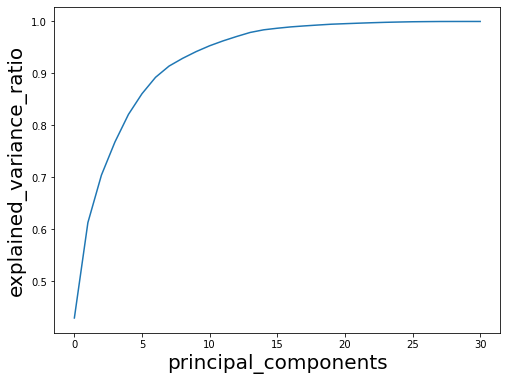

In [66]:
plt.figure(figsize=(8,6))
plt.plot(np.cumsum(principal_components.explained_variance_ratio_))
plt.grid(False)
plt.xlabel('principal_components', fontsize=20)
plt.ylabel('explained_variance_ratio', fontsize=20)
plt.show()

In [67]:
principal_components_3 = PCA(n_components=15)
fitted_principal_components_3 = principal_components_3.fit_transform(scaled_X)

In [68]:
component_df3 = pd.DataFrame(data=fitted_principal_components_3,columns=["First Component","Second Component",
                                                                     "Third Component","Fourth Component","Fifth Component"
                                                                    ,"sixth component","seventh component","8th","9th","10th",
                                                                        "11th","12th","13th","14th","15th" ])

In [69]:
component_df3.head(10)

,First Component,Second Component,Third Component,Fourth Component,Fifth Component,sixth component,seventh component,8th,9th,10th,11th,12th,13th,14th,15th
0,9.183200,1.971271,-1.171625,3.639332,-1.193098,-1.372280,0.371844,2.180529,-0.231610,-0.090396,-0.875268,0.264552,-0.859598,0.104564,-0.690058
1,2.383298,-3.753459,-0.580229,1.127438,0.624850,-0.126616,-0.288270,0.044935,0.426916,-0.659939,1.085345,0.810103,0.158544,-0.945859,-0.651364
2,5.742472,-1.080350,-0.533088,0.903470,-0.180601,-0.401855,0.463188,-0.715209,-0.010712,-0.082305,0.426614,-0.603993,0.122955,-0.409017,0.014279
3,7.124384,10.272225,-3.150161,0.121512,-2.968055,-2.561668,1.950177,1.287990,1.272638,-1.171376,-1.219463,-1.138545,1.003894,-0.925912,-0.494980
4,3.945694,-1.959689,1.401177,2.937555,0.540853,1.233300,-0.205435,-0.959329,0.629119,-0.166354,0.379517,0.649893,-0.109990,0.387836,-0.539593
5,2.371151,3.964910,-2.929342,0.925689,-1.061168,0.484059,-0.026803,0.500613,-0.095176,-0.113924,-0.542383,0.112519,0.079977,-0.024710,0.001933
6,2.233527,-2.674076,-1.675735,0.150643,0.041702,0.055813,-0.262267,-0.277779,0.126182,-0.034951,0.231516,0.391573,0.243243,-0.354477,-0.219379
7,2.151433,2.327691,-0.810728,-0.149408,-1.436901,1.367483,0.127457,0.953577,-0.755010,-0.044584,0.964659,-0.196162,-0.279323,-0.459299,-0.098342
8,3.165727,3.408826,-3.119277,-0.613053,-1.523496,-0.509189,0.172316,-0.207327,-0.809100,0.305970,0.024521,-0.559811,0.078999,0.494045,0.111157
9,6.354960,7.723539,-4.238290,-3.417145,1.696804,1.028651,0.804560,2.441868,0.525614,-0.574000,-1.218347,0.557849,-1.091387,-0.367377,-0.008225


In [70]:
principal_components_3.explained_variance_ratio_

array([0.42864701, 0.18376792, 0.09146436, 0.06391475, 0.05318759,
       0.03982815, 0.0315572 , 0.02166945, 0.01486427, 0.01300429,
       0.01126306, 0.00948034, 0.00842409, 0.00778485, 0.00506367])

In [71]:
np.sum(principal_components_3.explained_variance_ratio_)

0.9839209983607345

In [72]:
""" 
It is important to do the feature scaling before applying pca 
as to scale down all the numbers in the DF as the PCA directions are 
highly sensitive to the scale of the data.
"""

' \nIt is important to do the feature scaling before applying pca \nas to scale down all the numbers in the DF as the PCA directions are \nhighly sensitive to the scale of the data.\n'

# PCA 

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

#import statsmodels.api as sm
#import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn import preprocessing

#from sklearn.decomposition import PCA

from warnings import filterwarnings
filterwarnings("ignore")
import os
os.getcwd()

'C:\\Users\\User\\Desktop\\Batch Dec12th Stats ML\\Jan_27_PCA'

In [74]:
df = pd.read_csv("data.csv")

In [75]:
df["diagnosis"]=df["diagnosis"].map({"M":1,"B":1})

In [76]:
"""
# Create a dictionary using which we
# will remap the values
dict = {'M' : 1, 'B' : 0}
 
# Print the dictionary
print(dict)
 
# Remap the values of the dataframe
df.replace({"diagnosis": dict},inplace=True)
"""

'\n# Create a dictionary using which we\n# will remap the values\ndict = {\'M\' : 1, \'B\' : 0}\n \n# Print the dictionary\nprint(dict)\n \n# Remap the values of the dataframe\ndf.replace({"diagnosis": dict},inplace=True)\n'

In [77]:
df.drop("Unnamed: 32",axis=1,inplace=True)

In [78]:
df.head(100)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.990,10.38,122.80,1001.0,0.11840,0.27760,0.300100,0.147100,0.2419,0.07871,1.0950,0.9053,8.589,153.400,0.006399,0.049040,0.053730,0.015870,0.030030,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.711900,0.26540,0.4601,0.11890
1,842517,1,20.570,17.77,132.90,1326.0,0.08474,0.07864,0.086900,0.070170,0.1812,0.05667,0.5435,0.7339,3.398,74.080,0.005225,0.013080,0.018600,0.013400,0.013890,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.241600,0.18600,0.2750,0.08902
2,84300903,1,19.690,21.25,130.00,1203.0,0.10960,0.15990,0.197400,0.127900,0.2069,0.05999,0.7456,0.7869,4.585,94.030,0.006150,0.040060,0.038320,0.020580,0.022500,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.450400,0.24300,0.3613,0.08758
3,84348301,1,11.420,20.38,77.58,386.1,0.14250,0.28390,0.241400,0.105200,0.2597,0.09744,0.4956,1.1560,3.445,27.230,0.009110,0.074580,0.056610,0.018670,0.059630,0.009208,14.910,26.50,98.87,567.7,0.20980,0.86630,0.686900,0.25750,0.6638,0.17300
4,84358402,1,20.290,14.34,135.10,1297.0,0.10030,0.13280,0.198000,0.104300,0.1809,0.05883,0.7572,0.7813,5.438,94.440,0.011490,0.024610,0.056880,0.018850,0.017560,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.400000,0.16250,0.2364,0.07678
5,843786,1,12.450,15.70,82.57,477.1,0.12780,0.17000,0.157800,0.080890,0.2087,0.07613,0.3345,0.8902,2.217,27.190,0.007510,0.033450,0.036720,0.011370,0.021650,0.005082,15.470,23.75,103.40,741.6,0.17910,0.52490,0.535500,0.17410,0.3985,0.12440
6,844359,1,18.250,19.98,119.60,1040.0,0.09463,0.10900,0.112700,0.074000,0.1794,0.05742,0.4467,0.7732,3.180,53.910,0.004314,0.013820,0.022540,0.010390,0.013690,0.002179,22.880,27.66,153.20,1606.0,0.14420,0.25760,0.378400,0.19320,0.3063,0.08368
7,84458202,1,13.710,20.83,90.20,577.9,0.11890,0.16450,0.093660,0.059850,0.2196,0.07451,0.5835,1.3770,3.856,50.960,0.008805,0.030290,0.024880,0.014480,0.014860,0.005412,17.060,28.14,110.60,897.0,0.16540,0.36820,0.267800,0.15560,0.3196,0.11510
8,844981,1,13.000,21.82,87.50,519.8,0.12730,0.19320,0.185900,0.093530,0.2350,0.07389,0.3063,1.0020,2.406,24.320,0.005731,0.035020,0.035530,0.012260,0.021430,0.003749,15.490,30.73,106.20,739.3,0.17030,0.54010,0.539000,0.20600,0.4378,0.10720
9,84501001,1,12.460,24.04,83.97,475.9,0.11860,0.23960,0.227300,0.085430,0.2030,0.08243,0.2976,1.5990,2.039,23.940,0.007149,0.072170,0.077430,0.014320,0.017890,0.010080,15.090,40.68,97.65,711.4,0.18530,1.05800,1.105000,0.22100,0.4366,0.20750


In [79]:
X=df.drop("diagnosis",axis=1)
Y=df["diagnosis"]

In [80]:
scaler1 = StandardScaler()
X_s = scaler1.fit_transform(X)

# before apply pca accuracy

In [81]:
# before apply pca

# splitting the dataset into training and test data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X_s,Y,test_size=0.25,random_state=101,stratify=Y)

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

In [82]:
# predicting the test set result
y_pred=rf.predict(x_test)
# creating confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm


array([[143]], dtype=int64)

In [83]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

print("CLASSIFIER TESTING ACCURACY ",accuracy_score(y_test,y_pred))

CLASSIFIER TESTING ACCURACY  1.0


# APPLYING PCA

In [84]:
from sklearn.decomposition import PCA
pca = PCA()
pca = pca.fit(X_s)




In [85]:
pca.explained_variance_ratio_

array([4.28647013e-01, 1.83767915e-01, 9.14643564e-02, 6.39147476e-02,
       5.31875905e-02, 3.98281519e-02, 3.15572013e-02, 2.16694506e-02,
       1.48642719e-02, 1.30042934e-02, 1.12630637e-02, 9.48033657e-03,
       8.42409435e-03, 7.78484562e-03, 5.06366610e-03, 3.03640406e-03,
       2.57451447e-03, 1.90471846e-03, 1.69649015e-03, 1.58457831e-03,
       1.00228336e-03, 9.65845343e-04, 8.84855607e-04, 7.82226523e-04,
       5.81914867e-04, 4.99346119e-04, 2.63603188e-04, 2.22519447e-04,
       5.12689531e-05, 2.41411630e-05, 4.29161956e-06])

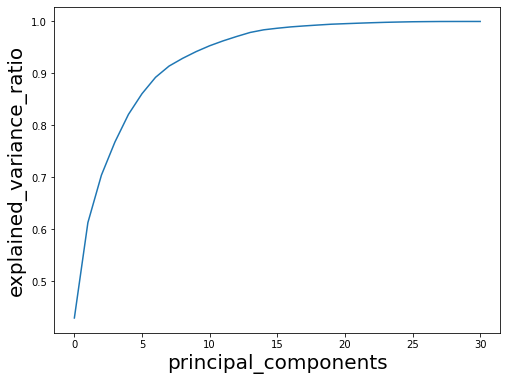

In [86]:
plt.figure(figsize=(8,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.grid(False)
plt.xlabel('principal_components', fontsize=20)
plt.ylabel('explained_variance_ratio', fontsize=20)
plt.show()

In [87]:
# calculation of principal components

In [88]:
pca_15 = PCA(n_components=15)
pca_applied = pca_15.fit_transform(X_s)

In [89]:
pca_applied_df = pd.DataFrame(data=pca_applied,columns=["First Component","Second Component",
                                                                     "Third Component","Fourth Component","Fifth Component"
                                                                    ,"sixth component","seventh component","8th","9th","10th",
                                                                        "11th","12th","13th","14th","15th" ])

In [90]:
pca_applied_df.head()

,First Component,Second Component,Third Component,Fourth Component,Fifth Component,sixth component,seventh component,8th,9th,10th,11th,12th,13th,14th,15th
0,9.183200,1.971271,-1.171625,3.639332,-1.193098,-1.372281,0.371844,2.180529,-0.231610,-0.090401,-0.875273,0.264536,-0.859592,0.104544,-0.690042
1,2.383298,-3.753459,-0.580229,1.127438,0.624850,-0.126616,-0.288270,0.044935,0.426916,-0.659941,1.085344,0.810098,0.158546,-0.945867,-0.651356
2,5.742472,-1.080350,-0.533088,0.903470,-0.180601,-0.401855,0.463188,-0.715209,-0.010712,-0.082303,0.426616,-0.603987,0.122951,-0.409008,0.014273
3,7.124384,10.272225,-3.150161,0.121512,-2.968055,-2.561668,1.950177,1.287990,1.272638,-1.171375,-1.219463,-1.138542,1.003891,-0.925910,-0.494974
4,3.945694,-1.959689,1.401177,2.937555,0.540853,1.233300,-0.205435,-0.959329,0.629119,-0.166353,0.379518,0.649895,-0.109991,0.387839,-0.539595


In [91]:
explained_VR=pca_15.explained_variance_ratio_
explained_VR

array([0.42864701, 0.18376792, 0.09146436, 0.06391475, 0.05318759,
       0.03982815, 0.0315572 , 0.02166945, 0.01486427, 0.01300429,
       0.01126306, 0.00948034, 0.00842409, 0.00778485, 0.00506367])

In [92]:
#np.sum(pca_15.explained_variance_ratio_)
np.sum(explained_VR)

0.9839209983539361

# after apply pca accuracy

In [93]:
# splitting the dataset into training and test data
from sklearn.model_selection import train_test_split
x_train1,x_test1,y_train1,y_test1=train_test_split(pca_applied_df,Y,test_size=0.25,random_state=101,stratify=Y)

In [94]:
from sklearn.ensemble import RandomForestClassifier

In [95]:
rf1=RandomForestClassifier()

In [96]:
rf1.fit(x_train1,y_train1)

RandomForestClassifier()

In [97]:
pred1=rf1.predict(x_test1)

In [98]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,pred1)
cm

array([[143]], dtype=int64)

In [99]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

print("CLASSIFIER TESTING ACCURACY ",accuracy_score(y_test1,pred1))

CLASSIFIER TESTING ACCURACY  1.0


In [100]:
"""Steps of PCA

(1)After Getting original data, calculate covariance matrix.

(2)Calculate EigenVectors.

(3)Sort EigenVectors by Eigenvalues.

(4)Choose N largest EigenValues.

(5)Project Original data onto EigenVectors."""

'Steps of PCA\n\n(1)After Getting original data, calculate covariance matrix.\n\n(2)Calculate EigenVectors.\n\n(3)Sort EigenVectors by Eigenvalues.\n\n(4)Choose N largest EigenValues.\n\n(5)Project Original data onto EigenVectors.'